In [2]:
import matplotlib.pyplot as plt

# Following is required to import any module 
import sys
sys.path.append('..')
from src.util.dataset import DichasusDataset
from src.util.misc import *
import importlib


In [3]:
importlib.reload(sys.modules['src.util.dataset']) 
# device = get_device()
device='cpu'
training_data = DichasusDataset("labeled_tdomain.npz", device=device)

# 1. Extract tensors
csi_time_domain = training_data.csi  # [N, ...]
groundtruth_positions = training_data.pos.float()  # [N, ...]
timestamps = training_data.time  # [N]

# 2. Process timestamps
MEASUREMENT_INTERVAL = 0.048
timestamps = timestamps - timestamps[0]
timestamps = torch.round(timestamps / MEASUREMENT_INTERVAL) * MEASUREMENT_INTERVAL

print(csi_time_domain.shape)
print(groundtruth_positions.shape)
print(timestamps.shape)


torch.Size([4651, 4, 2, 4, 64])
torch.Size([4651, 3])
torch.Size([4651])


### Angle Delay Profile Dissimilarity

In [4]:
from src.util.dissimilarity_metrics import ADPDissimilarityMetric
# importlib.reload(sys.modules['ADPDissimilarityMetric']) 
def mean_variance_from_delta_adp(delta_adp):
    mean = torch.where(delta_adp == 0, 0, torch.where(delta_adp > 18, torch.inf, delta_adp * 0.0028 + 0.0024))
    variance = torch.where(delta_adp == 0, 0, torch.where(delta_adp > 18, torch.inf, 0.015 * mean))

    return mean, variance

adp_metric = ADPDissimilarityMetric(csi_time_domain, mean_variance_from_delta_adp)

Computing ADP dissimilarity matrix...
ADP dissimilarity matrix computed
ADP dissimilarity matrix shape: torch.Size([4651, 4651])


### Timestamp/Velocity-Based Dissimilarity

In [5]:
from src.util.dissimilarity_metrics import VelocityDissimilarityMetric
# importlib.reload(sys.modules['src.util.dissimilarity_metrics'])
velocity_mean = 0.235
velocity_variance = 0.010

# Make worst-case assumption of perfectly correlated velocities. This maximizes the variance.
velocity_metric = VelocityDissimilarityMetric(velocity_mean, velocity_variance, True, timestamps)

### Gaussian Dissimilarity Model and short path computation

In [4]:
from src.models.gaussian_dissimilarity import GaussianDissimilarityModel
# importlib.reload(sys.modules['src.models.gaussian_dissimilarity'])
have_I_already_preprocessed = True
if not have_I_already_preprocessed:
    GDM = GaussianDissimilarityModel([adp_metric, velocity_metric])
    GDM.generate_short_paths(total_path_count = 32000, realization_count = 8)
    GDM.save()
    have_I_already_preprocessed = True
else:
    GDM = GaussianDissimilarityModel.load()

Loading model from /Users/ilirgusija/projects/competitions/signal-sifters/notebooks/../../data/processed/preprocessed/gdm_model_torch.pkl


## Channel Chart Training

### Hyperparameters

In [5]:
EPOCHS = 10
MIN_BATCH_SIZE = 500
MAX_BATCH_SIZE = 4000
LEARNING_RATE_INITIAL = 1.5e-2
LEARNING_RATE_FINAL = 1e-2
MAX_HOPLENGTH = 20.0
MIN_HOPLENGTH = 0.1
RANDOMIZE_PATHHOPS = False
PLOT_CALLBACK = None
TRAINING_BATCHES = 3000
ACCELERATION_MEAN = 0.0
ACCELERATION_VARIANCE = 0.5
ACCELERATION_WEIGHT = 1e-4    
MAX_PATHHOPS = 100

### Dataset

In [6]:
from torch.utils.data import DataLoader
from src.util.dataset import ChannelChartingPathDataset
have_I_already_preprocessed = True

In [7]:
importlib.reload(sys.modules['src.util.dataset'])
if not have_I_already_preprocessed:
    training_dataset = ChannelChartingPathDataset(
        GDM,
        csi_time_domain,
        training_batches=TRAINING_BATCHES,
        max_pathhops=MAX_PATHHOPS,
        min_batch_size=MIN_BATCH_SIZE,
        max_batch_size=MAX_BATCH_SIZE,
        min_hoplength=MIN_HOPLENGTH,
        max_hoplength=MAX_HOPLENGTH,
        randomize_pathhops=RANDOMIZE_PATHHOPS,
        device=device
    )
    training_dataset.save()
    have_I_already_preprocessed = True
else:
    training_dataset = ChannelChartingPathDataset.load(GDM, csi_time_domain, device='cpu')

In [8]:
# For now, we set this to 1 since we are doing most of the heavy lifting in the dataset class
dataloader = DataLoader(training_dataset, batch_size=1, shuffle=False)

### Loss Function

In [9]:
from src.util.loss import ChannelChartingLoss
importlib.reload(sys.modules['src.util.loss'])
loss_fn = ChannelChartingLoss(
    timestamps,
    acceleration_mean=ACCELERATION_MEAN,
    acceleration_variance=ACCELERATION_VARIANCE,
    acceleration_weight=ACCELERATION_WEIGHT
)

### Initialize Model

In [10]:
from src.models.channel_charting import ChannelChart
importlib.reload(sys.modules['src.models.channel_charting'])

model = ChannelChart(csi_time_domain)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE_INITIAL)
learning_rate_decay_factor = LEARNING_RATE_FINAL / LEARNING_RATE_INITIAL
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lr_lambda=lambda epoch: learning_rate_decay_factor ** (epoch / max(EPOCHS-1, 1))
)

### Train

In [15]:
# shed last dimension of groundtruth_positions
groundtruth_positions = groundtruth_positions[:, :2]

# convert to float32
groundtruth_positions = groundtruth_positions.to(torch.float32)
print(groundtruth_positions.shape)

torch.Size([4651, 2])


In [18]:
importlib.reload(sys.modules['src.util.misc'])
from src.util.misc import PlotChartCallback
plot_callback = PlotChartCallback(groundtruth_positions, csi_time_domain.shape[0])
plot_callback.set_model(model)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/3000 [00:00<?, ?it/s]

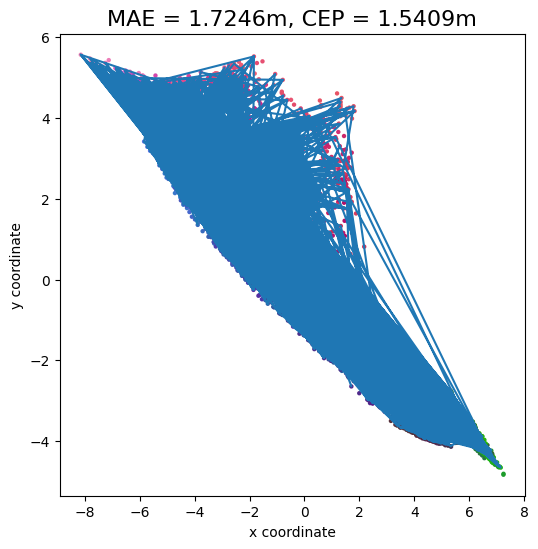

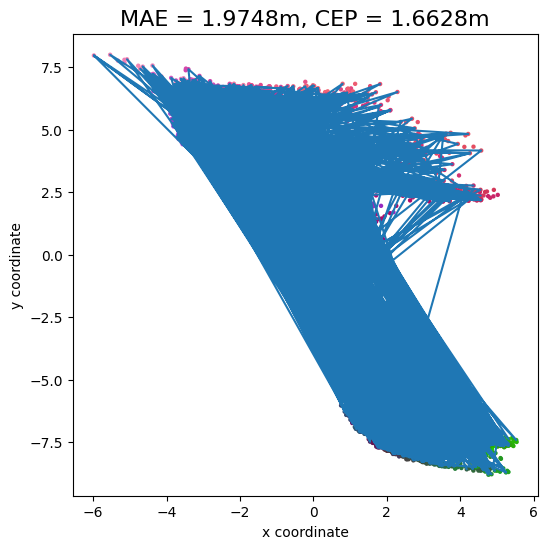

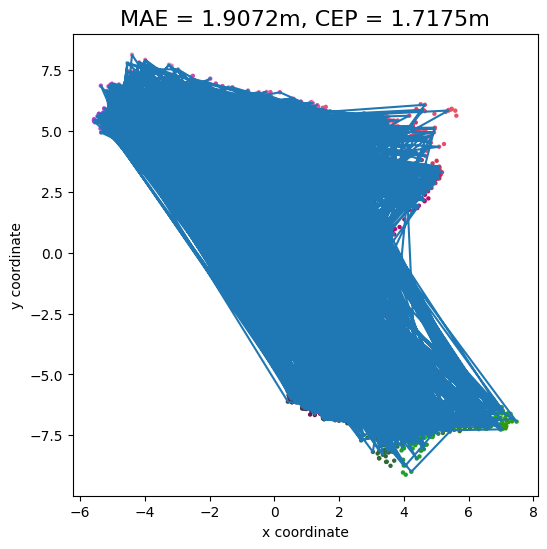

In [ ]:
from src.scripts.train_channel_chart import train
importlib.reload(sys.modules['src.scripts.train_channel_chart'])

train(model, dataloader, optimizer, scheduler, loss_fn, epochs=EPOCHS, device='cpu', plot_callback=plot_callback)
